In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc, cm
import matplotlib as mpl

# 마이너스 깨짐 현상 해결
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'

In [2]:
path = './data/'

raw = pd.read_csv(path+'pima-indians-diabetes3.csv')
diabetes = raw.copy()
print(diabetes.shape)
diabetes.head(2)

(768, 9)


,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


## EDA

In [3]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   bmi        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   diabetes   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
diabetes.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# 정상과 당뇨병환자 각각 몇 명인지 조사하기


In [6]:
# 상관계수 확인
diabetes.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


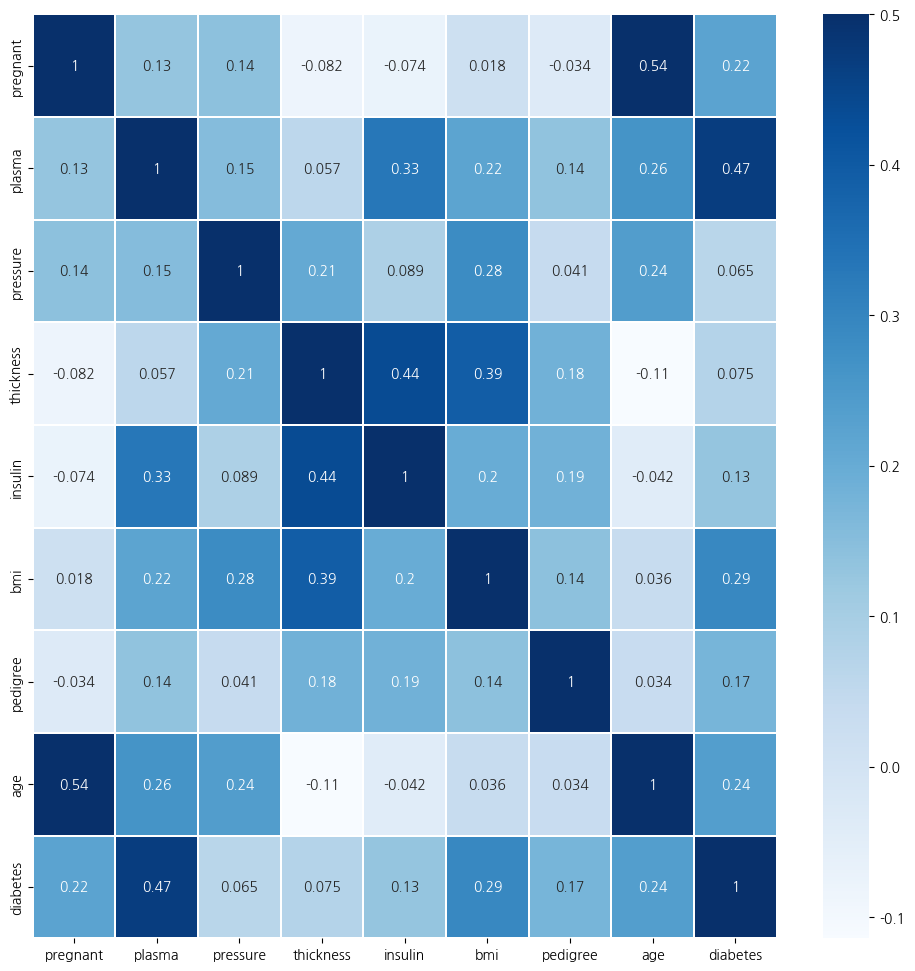

In [7]:
# 데이터 간 상관관계 시각화
colormap = plt.cm.Blues

# 밑 바탕 생성
plt.figure(figsize=(12, 12))

# 그래프 속성 결정 (vmax = 0.5 >> 0.5에 가까우면 밝은 색)
sns.heatmap(diabetes.corr(), linewidths=0.1, vmax=0.5, cmap=colormap, linecolor='white', annot=True)
plt.show()

## 중요한 데이터 속성 추출
* 관계성 파악에 NGD 기법을 사용할수도 있지만, 시간이 너무 오래걸린다. 따라서 논문, 문헌 정보를 확인한 후, 파악하는 것이 더 현명한 방법일 수 있다.

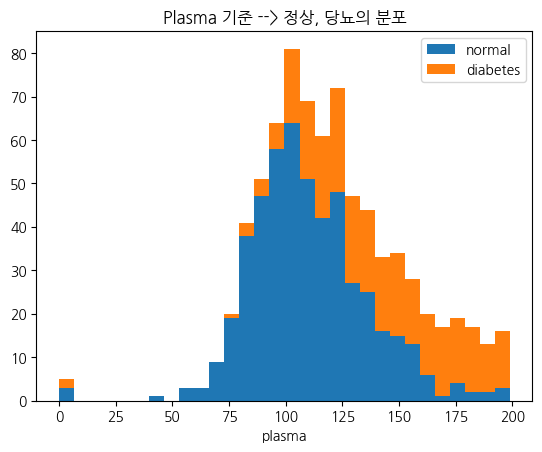

In [8]:
# plasma 기준, 정상/당뇨가 어느 정도 비율로 분포하는지 살펴보기
plt.hist(x=[diabetes.plasma[diabetes.diabetes == 0], diabetes.plasma[diabetes.diabetes == 1]],
         bins=30,
         histtype='barstacked',
         label=['normal', 'diabetes'])

plt.title('Plasma 기준 --> 정상, 당뇨의 분포')
plt.xlabel('plasma')
plt.legend()
plt.show()

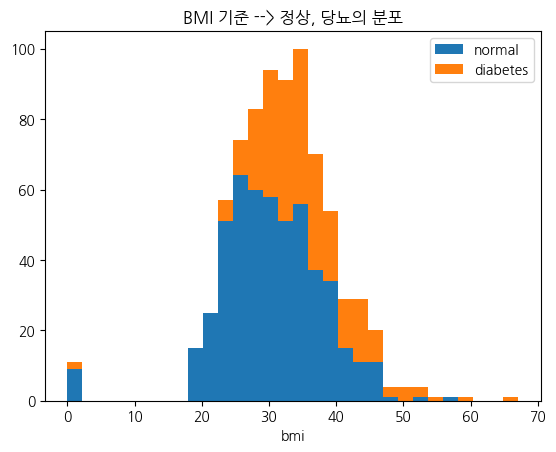

In [9]:
# BMI 기준, 정상/당뇨가 어느 정도 비율로 분포하는지 살펴보기
plt.hist(x=[diabetes.bmi[diabetes.diabetes == 0], diabetes.bmi[diabetes.diabetes == 1]],
         bins=30,
         histtype='barstacked',
         label=['normal', 'diabetes'])

plt.title('BMI 기준 --> 정상, 당뇨의 분포')
plt.xlabel('bmi')
plt.legend()
plt.show()

## 피마 인디언 당뇨병 예측 실행하기

In [10]:
# 필요한 라이브러리 로드
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
# 데이터 준비
# 독립변수
X = diabetes.iloc[:, :-1]
# 종속변수
y = diabetes.diabetes

# 모델 설계
model = Sequential()
# 은닉층 1
model.add(Dense(12, input_dim=8, activation='relu', name='Dense_1'))
# 은닉층 2
model.add(Dense(8, activation='relu', name='Dense_2'))
# 이진분류 (정상 : 0, 당뇨 : 1)
model.add(Dense(1, activation='sigmoid', name='Dense_3'))

model.summary()

C:\Users\tjdtn\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                      │ (None, 12)                  │             108 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 모델 환경설정
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 실행
history = model.fit(X, y, epochs=100, batch_size=5)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5474 - loss: 8.4631
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5313 - loss: 1.7819
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6025 - loss: 0.8278
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6326 - loss: 0.6899
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6583 - loss: 0.6284
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6459 - loss: 0.6410
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6406 - loss: 0.6452
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6684 - loss: 0.6437
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6554 - loss: 0.6585
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6916 - loss: 0.6530
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6594 - loss: 0.6121
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━━